# TDA of Chicago Crime Patterns - Focused 26-Community Analysis

Focused analysis of the 26 selected communities reported in the final write-up, using the same analytical pipeline as the overall notebook.


In [ ]:
# Reproducible path configuration for Colab and local runs
from pathlib import Path
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/tda_crime')
else:
    cwd = Path.cwd()
    PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUT_DIR / 'figures'
ARTIFACT_DIR = OUTPUT_DIR / 'artifacts'
REPORT_DIR = PROJECT_ROOT / 'report'

for path in [DATA_DIR, FIGURES_DIR, ARTIFACT_DIR, REPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

def first_existing_path(*candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    return Path(candidates[0])

CRIME_DATA_PATH = first_existing_path(
    DATA_DIR / 'Crimes_-_2001_to_Present_20260401.csv',
    PROJECT_ROOT / 'Crimes_-_2001_to_Present_20260401.csv',
)
BOUNDARIES_PATH = first_existing_path(
    DATA_DIR / 'Boundaries_-_Community_Areas_20260506.geojson',
    PROJECT_ROOT / 'Boundaries_-_Community_Areas_20260506.geojson',
)
ACS_FEATURES_PATH = first_existing_path(
    DATA_DIR / 'ACS_ChicagoFeatures_2019_2023.csv',
    PROJECT_ROOT / 'ACS_ChicagoFeatures_2019_2023.csv',
)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Figures directory: {FIGURES_DIR}')
print(f'Artifact directory: {ARTIFACT_DIR}')


In [ ]:
# Install KeplerMapper only when it is missing.
try:
    import kmapper as km
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kmapper'])
    import kmapper as km


In [ ]:
import pandas as pd
import datetime as dt
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.colors import ListedColormap, BoundaryNorm
import plotly.graph_objects as go
from plotly.colors import sample_colorscale

import kmapper as km
from sklearn.cluster import AgglomerativeClustering
from sklearn.base import BaseEstimator, ClusterMixin
import statsmodels.api as sm

from scipy.stats import entropy, spearmanr


In [ ]:
pd.set_option('display.max_columns', None)


In [ ]:
special_communities = [23, 26, 29, 32, 33, 35, 36, 37, 38, 40, 42, 43, 44, 45, 46, 47, 48, 49, 51, 53, 54, 55, 62, 69, 71, 73]
special_communities = [str(x) for x in special_communities]


In [ ]:
directory = 'focused_26_communities'


# Data Cleaning and Preprocessing

In [ ]:
data = pd.read_csv(CRIME_DATA_PATH, dtype={'Community Area': str, 'FBI Code': str}, sep=',', engine='python', quotechar='"', on_bad_lines='skip')


In [ ]:
#rename Community Area column
data.rename(columns={'Community Area': 'Community',
                     'FBI Code': 'FBI',
                     'Primary Type': 'PrimaryType'}, inplace=True)
data.rename(columns={}, inplace=True)


In [ ]:
data.info()


In [ ]:
data.head()


In [ ]:
data['Year'].value_counts()


In [ ]:
data = data[(data['Year'] >= 2018) & (data['Year'] <= 2023)]


In [ ]:
data.shape


In [ ]:
data['Year'].value_counts()


In [ ]:
#Change Date column format
data['Datetime'] = pd.to_datetime(data['Date'], format='%m/%d/%Y %I:%M:%S %p')


In [ ]:
data['YMonth'] = data['Datetime'].dt.year.astype('str') + np.where(data['Datetime'].dt.month<10, '0', '') + data['Datetime'].dt.month.astype('str')

data["Month"] = np.where(data['Datetime'].dt.month<10, '0', '') + data['Datetime'].dt.month.astype('str')

def get_period_date(m):
    if m < pd.Timestamp("2020-01-01"):
        return "Pre-COVID"
    elif m < pd.Timestamp("2022-01-01"):
        return "COVID"
    else:
        return "Post-COVID"

data["Period"] = data["Datetime"].apply(get_period_date)


In [ ]:
year_counts = data['Year'].value_counts().reset_index()
year_counts.columns = ['Year', 'Count']
year_counts.sort_values(by='Year')


In [ ]:
data = data[data["Community"].isin(special_communities)]


In [ ]:
timeseries = data.pivot_table(index='YMonth', values='ID', aggfunc='count').reset_index()


In [ ]:
plt.figure(figsize=(25, 6))

#Create a lineplot
sns.lineplot(x='YMonth', y='ID', data=timeseries, color='hotpink')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=90)
plt.show()


In [ ]:
data.columns = data.columns.str.strip()


In [ ]:
len(data['PrimaryType'].unique())


In [ ]:
data['PrimaryType'].value_counts(1).reset_index()


In [ ]:
# Crime type taxonomy mapping
CRIME_TAXONOMY = {
    # Top 12: keep as-is
    'THEFT': ['THEFT'],
    'BATTERY': ['BATTERY'],
    'CRIMINAL DAMAGE': ['CRIMINAL DAMAGE'],
    'ASSAULT': ['ASSAULT'],
    'DECEPTIVE PRACTICE': ['DECEPTIVE PRACTICE'],
    'OTHER OFFENSE': ['OTHER OFFENSE'],
    'MOTOR VEHICLE THEFT': ['MOTOR VEHICLE THEFT'],
    'BURGLARY': ['BURGLARY'],
    'ROBBERY': ['ROBBERY'],
    'NARCOTICS': ['NARCOTICS', 'OTHER NARCOTIC VIOLATION'],
    'WEAPONS VIOLATION': ['WEAPONS VIOLATION', 'CONCEALED CARRY LICENSE VIOLATION'],
    'CRIMINAL TRESPASS': ['CRIMINAL TRESPASS'],
    # Grouped categories
    'SEXUAL CRIMES': ['SEX OFFENSE', 'CRIMINAL SEXUAL ASSAULT', 'CRIM SEXUAL ASSAULT',
                      'PROSTITUTION', 'PUBLIC INDECENCY', 'OBSCENITY'],
    'PUBLIC ORDER': ['PUBLIC PEACE VIOLATION', 'INTERFERENCE WITH PUBLIC OFFICER',
                     'LIQUOR LAW VIOLATION', 'ARSON', 'GAMBLING',
                     'NON-CRIMINAL', 'RITUALISM'],
    # Merge the two <1% groups into OTHER
    'OTHER CRIMES': ['OFFENSE INVOLVING CHILDREN', 'HOMICIDE', 'KIDNAPPING',
                     'STALKING', 'INTIMIDATION', 'HUMAN TRAFFICKING'],
}

reverse_map = {}
for new_cat, old_cats in CRIME_TAXONOMY.items():
    for old in old_cats:
        reverse_map[old] = new_cat

data['crime_category'] = data['PrimaryType'].map(reverse_map)


In [ ]:
###Create First Dataset (compositional)
##create a crosstab and show totals

composition = pd.crosstab(index = [data['Community'], data['YMonth'], data['Year'], data['Month'], data['Period']], columns=data['crime_category'], values=data['ID'], aggfunc='count', normalize=False,margins=True).fillna(0).reset_index()
composition = composition[composition['Community']!='All'].reset_index(drop=True)


In [ ]:
composition.columns


In [ ]:
composition[composition['Community']=='26'].sort_values('All')


In [ ]:
crimes = ['ASSAULT', 'BATTERY',
       'BURGLARY', 'CRIMINAL DAMAGE', 'CRIMINAL TRESPASS',
       'DECEPTIVE PRACTICE', 'MOTOR VEHICLE THEFT', 'NARCOTICS',
       'OTHER CRIMES', 'OTHER OFFENSE', 'PUBLIC ORDER', 'ROBBERY',
       'SEXUAL CRIMES', 'THEFT', 'WEAPONS VIOLATION']


In [ ]:
composition_pct = composition.copy()

for col in crimes:
    composition_pct[col] = composition_pct[col]/composition_pct['All']

composition.sample(5)


In [ ]:
#CHECK 100%
composition_pct['All'] = composition_pct[crimes].sum(axis=1)

print('Min/Max All', np.min(composition_pct['All']), '/', np.max(composition_pct['All']))

composition_pct.head(3)

composition_pct.drop(columns=['All'], inplace=True)


In [ ]:

composition_pct["dominantCrime"] = composition_pct[crimes].idxmax(axis=1)
composition_pct["dominantCrimeShare"] = composition_pct[crimes].max(axis=1)


In [ ]:
composition_pct.sample(5)


In [ ]:
# Selecciona el renglón que quieras (aquí el primero, índice 0)
row = composition_pct[(composition_pct['Community']=="26") & (composition_pct['YMonth']=="202207")][crimes].iloc[0].sort_index()  # alfabético

fig, ax = plt.subplots(figsize=(4, 6))

ax.barh(row.index, row.values, color='#C2E812', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Proportion')
# ax.set_title('Crime distribution — Community A')
ax.invert_yaxis()  # para que A quede arriba

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
###Coloring variables
##Arrest
other_rates = (
    data.groupby(['Community', 'YMonth', 'Year', 'Month', 'Period'])
    .agg(
        arrestRate=('Arrest', 'mean'),
        domesticRate=('Domestic', 'mean')
    )
    .reset_index()
)


In [ ]:
other_rates


In [ ]:
composition_pct = composition_pct.merge(other_rates, on=['Community', 'YMonth', 'Year', 'Month', 'Period'], how='left')


# Distance Matrix

In [ ]:
#Set community and month as index in community_pct

community_pct = composition_pct.set_index(['Community', 'YMonth', 'Year', 'Month', 'Period'])


In [ ]:
community_pct.head(3)


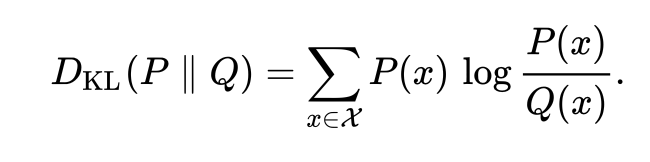

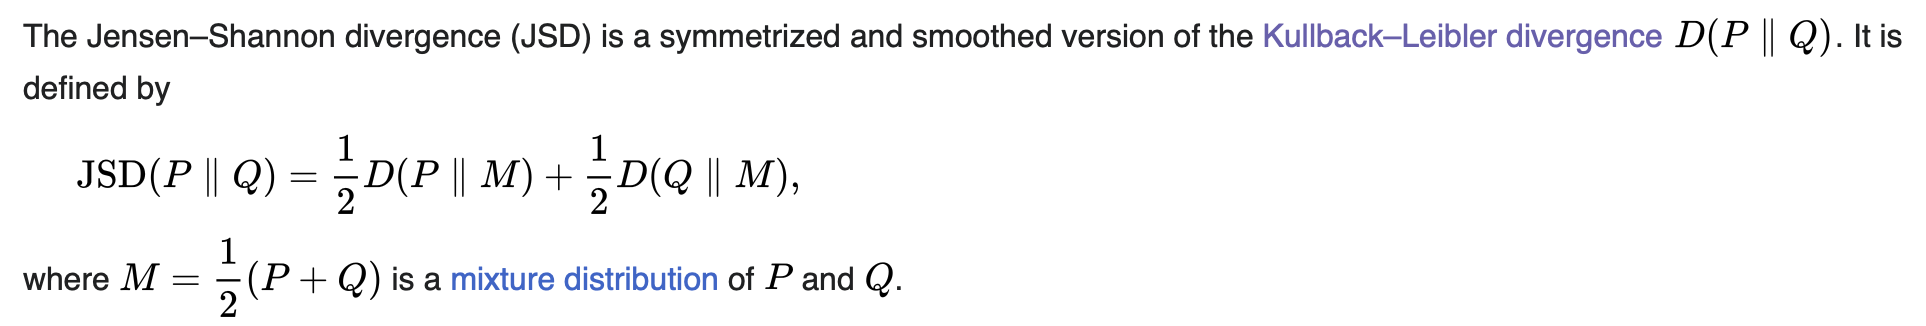

In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
import time


In [ ]:
X = community_pct[crimes].values  


In [ ]:
X.shape


In [ ]:
focused_artifact_dir = ARTIFACT_DIR / directory
focused_artifact_dir.mkdir(parents=True, exist_ok=True)

def jsd_matrix_fast(X):
    n = X.shape[0]
    X = np.clip(X, 1e-10, 1)
    X = X / X.sum(axis=1, keepdims=True)
    dist = np.zeros((n, n))
    batch = 500
    for i in range(0, n, batch):
        end_i = min(i + batch, n)
        Xi = X[i:end_i]
        for j in range(i, n, batch):
            end_j = min(j + batch, n)
            Xj = X[j:end_j]
            M = 0.5 * (Xi[:, None, :] + Xj[None, :, :])
            M = np.clip(M, 1e-10, 1)
            Xi_safe = np.clip(Xi[:, None, :], 1e-10, 1)
            Xj_safe = np.clip(Xj[None, :, :], 1e-10, 1)
            kl1 = np.sum(Xi_safe * np.log(Xi_safe / M), axis=2)
            kl2 = np.sum(Xj_safe * np.log(Xj_safe / M), axis=2)
            jsd = np.sqrt(np.clip(0.5 * (kl1 + kl2), 0, 1))
            dist[i:end_i, j:end_j] = jsd
            dist[j:end_j, i:end_i] = jsd.T
    np.fill_diagonal(dist, 0)
    return dist



In [ ]:
start = time.time()
dist_matrix = jsd_matrix_fast(X)
print(f"{(time.time()-start)/60:.2f} min")

#save
np.save(focused_artifact_dir / 'jsd_matrix_final.npy', dist_matrix)
print(f"Saved, shape: {dist_matrix.shape}, Max: {dist_matrix.max():.4f}")


In [ ]:
#Validacion

print(f"Simmetric? {np.allclose(dist_matrix, dist_matrix.T)}")
print(f"Zero diagonal {np.allclose(np.diag(dist_matrix), 0)}")
print(f"values in [0, ~0.83]? Max={dist_matrix.max():.4f}")


# PCoA

In [ ]:


# PCoA = double centering + eigendecomp
def pcoa_fast(D):
    n = D.shape[0]
    # Double centering
    D2 = D ** 2
    row_mean = D2.mean(axis=1, keepdims=True)
    col_mean = D2.mean(axis=0, keepdims=True)
    grand_mean = D2.mean()
    B = -0.5 * (D2 - row_mean - col_mean + grand_mean)
    # Eigendecomp
    eigvals, eigvecs = np.linalg.eigh(B)
    # Descending 
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    # Only positive components
    eigvals_pos = np.maximum(eigvals, 0)
    coords = eigvecs[:, :2] * np.sqrt(eigvals_pos[:2])
    return coords, eigvals


In [ ]:
lens_raw, eigvals = pcoa_fast(dist_matrix)

lens_ranked = np.column_stack([
    pd.Series(lens_raw[:, 0]).rank(method="average").to_numpy(),
    pd.Series(lens_raw[:, 1]).rank(method="average").to_numpy()
])


In [ ]:
np.save(focused_artifact_dir / 'lens_pcoa.npy', lens_raw)


In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(lens_raw[:,0], lens_raw[:,1], alpha=0.3, s=5, color='#40476D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCoA -  Chicago compositional space')


In [ ]:
years = community_pct.index.get_level_values('Year')

plt.figure(figsize=(8,6))
sc = plt.scatter(lens_raw[:,0], lens_raw[:,1], c=years, cmap='RdBu', alpha=0.3, s=3)

plt.colorbar(sc, label='Año')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCoA by year')
plt.show()


In [ ]:
periods = community_pct.index.get_level_values('Period')

period_labels = ['Pre-COVID', 'COVID', 'Post-COVID']
period_num = np.array([period_labels.index(p) for p in periods])

cmap = ListedColormap(['#6CCFF6', '#FF5964', '#C2E812'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

plt.figure(figsize=(8, 6))
sc = plt.scatter(lens_raw[:, 0], lens_raw[:, 1], c=period_num, cmap=cmap, norm=norm, alpha=0.5, s=3)
cbar = plt.colorbar(sc, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(period_labels)
cbar.set_label('Period')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCoA by Period')
plt.show()


In [ ]:

plt.figure(figsize=(8, 6))
sc = plt.scatter(lens_ranked[:, 0], lens_ranked[:, 1], c=period_num, cmap=cmap, norm=norm, alpha=0.5, s=3)
cbar = plt.colorbar(sc, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(period_labels)
cbar.set_label('Period')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCoA (ranked) by Period')
plt.show()


# Mapper

In [ ]:
# Single linkage clustering wrapper for precomputed distance submatrices.
class SingleLinkagePrecomputed(BaseEstimator, ClusterMixin):
    def __init__(self, cut_distance=0.5):
        self.cut_distance = cut_distance

    def fit_predict(self, X, y=None):
        if X.shape[0] == 1:
            return np.array([0])
        # Keep the square submatrix expected by the precomputed-distance clusterer.
        n = X.shape[0]
        sub = X[:, :n]
        clustering = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=self.cut_distance,
            linkage='single',
            metric='precomputed'
        )
        return clustering.fit_predict(sub)



In [ ]:
n = dist_matrix.shape[0]

#Turn into 1-d array (just top of the mtx)
idx_sup = np.triu_indices(n, k=1)
pure_dist = dist_matrix[idx_sup]

sns.histplot(pure_dist, kde=True)
plt.title("Intra-Samples Distances")
plt.show()



In [ ]:
print("Mean:", round(pure_dist.mean(),2), "| StD:", round(pure_dist.std(),2), "| Mean + STD:", round(pure_dist.mean() + pure_dist.std(),2), "| Mean + 2STD:", round(pure_dist.mean() + 2*pure_dist.std(),2))


## Parameter Search and Robustness Checks

In [ ]:
#------------Test 1:  parameters from the original paper to calibrate heuristically, using similar rules (nodes > 1 sample and max(nodes_size)=10%)
## Notes: almost one node per sample = a lot of nodes with just one sample & bigget node with 13% of the samples
# Mapper
mapper = km.KeplerMapper(verbose=1)

clusterer = SingleLinkagePrecomputed(cut_distance=0.2)

graph = mapper.map(
    lens_ranked,
    dist_matrix,
    cover=km.Cover(n_cubes=15, perc_overlap=0.7),
    clusterer=clusterer
)

#Results
node_sizes = [len(v) for v in graph['nodes'].values()]
print(f"Nodes: {len(node_sizes)}")
print(f"Edges: {sum(len(v) for v in graph['links'].values())}")
print(f"Largest node: {max(node_sizes)} ({max(node_sizes)/9240*100:.1f}%)")
print(f"Smallest: {min(node_sizes)}")
print(f"Singletons: {sum(1 for s in node_sizes if s < 2)}")


In [ ]:
#-----------Test 2: (Grid 1) Check cut point (where single linkage cuts the dendogram), jsd max=0.75, mean=0.26 rules (nodes > 1 sample and max(nodes_size)=10%)
## Notes: cut = 0.5, 0.6 work, same graph (>cut doesn't change the graph), largest node still have 24% (probably, n_cubes=intervals are not enough and overlap is big)

for cut in [0.2, 0.25,  0.3, 0.35, 0.4, 0.45, 0.5]:
    graph = mapper.map(
        lens_ranked,
        dist_matrix,
        cover=km.Cover(n_cubes=15, perc_overlap=0.7),
        clusterer=SingleLinkagePrecomputed(cut_distance=cut)
    )
    if not graph['nodes']:
        print(f"cut={cut}: grafo vacío")
        continue
    node_sizes = [len(v) for v in graph['nodes'].values()]
    n_sing = sum(1 for s in node_sizes if s < 2)
    print(f"cut={cut} | nodos={len(node_sizes)} | edges= {sum(len(v) for v in graph['links'].values())} | max={max(node_sizes)} ({max(node_sizes)/9240*100:.1f}%) | min={min(node_sizes)} ({min(node_sizes)/9240*100:.1f}%)| singletons={n_sing}")


In [ ]:
#---------Test 3: (Grid 2) Fix cut (0.5), test more intervals and decrease overlap to avoid that a higher density region collapse in a single node.

mapper = km.KeplerMapper(verbose=0)  # verbose=0 no spam

for cdist in [0.35, 0.4, 0.45, 0.5]:
    for n_cubes in [10, 15, 20, 25, 30]:
        for overlap in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
            for inter in [1, 2, 3, 4, 5]:
                graph = mapper.map(
                    lens_ranked,
                    dist_matrix,
                    cover=km.Cover(n_cubes=n_cubes, perc_overlap=overlap),
                    clusterer=SingleLinkagePrecomputed(cut_distance=cdist),
                    nerve=km.GraphNerve(min_intersection=inter)
                )
                if not graph['nodes']:
                    continue
                node_sizes = [len(v) for v in graph['nodes'].values()]
                n_sing = sum(1 for s in node_sizes if s < 2)
                max_pct = max(node_sizes)/dist_matrix.shape[0]*100
                passes = (n_sing == 0) and (max_pct <= 10)
                print(f"cutdist = {cdist} cubes={n_cubes} overlap={overlap} min_inter ={inter} | nodes={len(node_sizes)} | edges= {sum(len(v) for v in graph['links'].values())} | max={max(node_sizes)} ({max_pct:.1f}%) | singletons={n_sing} | ok ={passes}")


## Final Mapper Parameters

Selected final Mapper parameters:

cutdist=0.45,  n_cubes=10, overlap=0.2

Robustness checks considered:

cutdist=0.45,  n_cubes=15, overlap=0.2

cutdist=0.45, n_cubes=10, overlap=0.5

In [ ]:
# fcubes = 10
# foverlap = 0.2
# fcut_dist = 0.45 
# fmin_int = 1
#Robustness
fcubes = 15
foverlap = 0.2
fcut_dist = 0.45 
fmin_int = 1


# fcubes = 10
# foverlap = 0.5
# fcut_dist = 0.45 
# fmin_int = 1


In [ ]:
mapper = km.KeplerMapper(verbose=1)

graph = mapper.map(
    lens_ranked,
    dist_matrix,
    cover=km.Cover(n_cubes=fcubes, perc_overlap=foverlap),
    clusterer=SingleLinkagePrecomputed(cut_distance=fcut_dist),
    nerve = km.GraphNerve(min_intersection=fmin_int)
)


# Density Estimation (knn)

In [ ]:
# ── Paso 1: kNN distance por muestra (sobre TODAS)
# k = 10% del total, redondeado — exactamente como el paper
k = round(0.1 * dist_matrix.shape[0])  
print(f"k = {k}")

# Versión vectorizada, rápida
dist_tmp = dist_matrix.copy()
np.fill_diagonal(dist_tmp, np.inf)                    # excluir self-distance
partitioned = np.partition(dist_tmp, k, axis=1)[:, :k]  # k vecinos más cercanos
knn_dist = partitioned.mean(axis=1)                   # promedio → shape (9240,)
del dist_tmp

print(f"knn_dist: min={knn_dist.min():.4f}, mean={knn_dist.mean():.4f}, max={knn_dist.max():.4f}")

# ── Paso 2 y 3: densidad por vértice del Mapper (Ec. 2 y 3 del paper)
node_density = {}
for node_id, members in graph['nodes'].items():
    n = len(members)
    sum_knn = knn_dist[members].sum()   # suma de kNN dist de los puntos en el vértice
    d_inv = sum_knn / (n ** 2)          # Ec. 2: D_inv(V) = sum / n²
    node_density[node_id] = 1.0 / d_inv  # Ec. 3: D(V) = 1 / D_inv

# Convertir a array de muestras para kmapper
density_per_sample = np.zeros(dist_matrix.shape[0])
for node_id, members in graph['nodes'].items():
    for idx in members:
        # Si una muestra está en varios nodos, tomar la densidad máxima
        density_per_sample[idx] = max(density_per_sample[idx], node_density[node_id])

# # Visualizar
# mapper.visualize(
#     graph,
#     title="Chicago Crime Mapper — KNN Density (k=924)",
#     path_html=str(FIGURES_DIR / directory / "mapper_density.html"),
#     color_values=density_per_sample,
#     color_function_name=f"KNN Density (k={k})"
# )

print("Node density:")
densities = list(node_density.values())
print(f"  min={min(densities):.4f}, mean={np.mean(densities):.4f}, max={max(densities):.4f}")


# Visualization

In [ ]:
##Mapper node table for plots

def mode_or_nan(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return x.value_counts().idxmax()

def prop_mode(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return x.value_counts(normalize=True).max()

def categorical_entropy(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    p = x.value_counts(normalize=True).values
    return entropy(p)

def build_node_table(graph, sample_df, node_density=None):
    rows = []

    for node_id, members in graph["nodes"].items():
        sub = sample_df.iloc[members].copy()

        row = {
            "node_id": node_id,
            "n_samples": len(members),

            # Period
            "period_majority": mode_or_nan(sub["Period"]),
            "period_majority_share": prop_mode(sub["Period"]),
            "period_entropy": categorical_entropy(sub["Period"]),

            # time
            "mean_year": sub["Year"].mean(),
            "min_year": sub["Year"].min(),
            "max_year": sub["Year"].max(),

            # community
            "community_majority": mode_or_nan(sub["Community"]),
            "community_majority_share": prop_mode(sub["Community"]),
            "n_communities": sub["Community"].nunique(),

            # crime
            "dominant_crime_majority": mode_or_nan(sub["dominantCrime"]),
            "dominant_crime_majority_share": prop_mode(sub["dominantCrime"]),
            "mean_dominant_crime_share": sub["dominantCrimeShare"].mean(),

            # existing external variables
            "mean_arrest_rate": sub["arrestRate"].mean(),
            "mean_domestic_rate": sub["domesticRate"].mean(),
        }

        if node_density is not None:
            row["density"] = node_density.get(node_id, np.nan)

        # optional: mean share per crime category
        for c in crimes:
            row[f"mean_{c}"] = sub[c].mean()

        rows.append(row)

    return pd.DataFrame(rows)



In [ ]:
community_pct.reset_index(inplace=True)


In [ ]:
node_df = build_node_table(graph, community_pct, node_density=node_density)
node_df.head()


In [ ]:
import networkx as nx

def graph_to_networkx(graph):
    G = nx.Graph()

    for node_id, members in graph["nodes"].items():
        G.add_node(node_id, n_samples=len(members))

    for source, targets in graph["links"].items():
        for target in targets:
            G.add_edge(source, target)

    return G

G = graph_to_networkx(graph)

# Layout fijo para que todos los colores usen la misma estructura
pos = nx.spring_layout(G, seed=42, k=0.18)

node_df["x"] = node_df["node_id"].map(lambda n: pos[n][0])
node_df["y"] = node_df["node_id"].map(lambda n: pos[n][1])


In [ ]:
node_df.columns


In [ ]:
acs_ca = pd.read_csv(ACS_FEATURES_PATH)


In [ ]:
def assign_acs_year(year):
    if year <= 2019:
        return 2019
    elif year <= 2021:
        return 2021
    else:
        return 2023

community_pct["acs_year"] = community_pct["Year"].apply(assign_acs_year)
community_pct["Community"] = community_pct["Community"].astype(str)
acs_ca["Community"] = acs_ca["Community"].astype(str)

df_acs = community_pct.merge(
    acs_ca,
    on=["Community", "acs_year"],
    how="left"
)


In [ ]:
acs_cols_to_average = [
    "poverty_rate",
    "unemployment_rate",
    "bachelors_plus_rate",
    "renter_rate",
    "vacancy_rate",
    "median_household_income_approx",
    "white_non_hispanic_rate",
    "black_non_hispanic_rate",
    "asian_non_hispanic_rate",
    "hispanic_rate"
]

def build_node_table_with_acs(graph, sample_df, node_density=None):
    node_df = build_node_table(graph, sample_df, node_density=node_density)

    acs_rows = []
    for node_id, members in graph["nodes"].items():
        sub = sample_df.iloc[members]
        row = {"node_id": node_id}

        for col in acs_cols_to_average:
            if col in sub.columns:
                row[f"mean_{col}"] = sub[col].mean()

        acs_rows.append(row)

    acs_node_df = pd.DataFrame(acs_rows)
    node_df = node_df.merge(acs_node_df, on="node_id", how="left")

    return node_df


In [ ]:
node_df = build_node_table_with_acs(graph, df_acs, node_density=node_density)


In [ ]:
G = graph_to_networkx(graph)

# Layout fijo para que todos los colores usen la misma estructura
pos = nx.spring_layout(G, seed=42, k=0.18)

node_df["x"] = node_df["node_id"].map(lambda n: pos[n][0])
node_df["y"] = node_df["node_id"].map(lambda n: pos[n][1])


In [ ]:
node_df.columns


In [ ]:

# ------------------------------------------------------------
# Base settings
# ------------------------------------------------------------

RAINBOW_SCALE = px.colors.sequential.Rainbow

DEFAULT_CONTINUOUS_COLS = {
    "community_majority_num",
    "n_communities",
    "mean_arrest_rate",
    "mean_domestic_rate",
    "density",
    "poverty_rate",
    "unemployment_rate",
    "bachelors_plus_rate",
    "renter_rate",
    "vacancy_rate",
    "mean_median_household_income_approx",
    "white_non_hispanic_rate",
    "black_non_hispanic_rate",
    "asian_non_hispanic_rate",
    "hispanic_rate",
    "period_majority_share",
    "n_samples"
}

DEFAULT_CATEGORICAL_COLS = {
    "period_majority",
    "dominant_crime_majority",
    "community_majority",   "state_label",
    "state_id"
}

PERIOD_ORDER = ["pre_covid", "covid", "post_covid", "missing"]

HOVER_COLS = [
    "node_id",
    "n_samples",
    "period_majority",
    "period_majority_share",
    "community_majority",
    "community_majority_num",
    "n_communities",
    "dominant_crime_majority",
    "mean_arrest_rate",
    "mean_domestic_rate",
    "density",
    "poverty_rate",
    "unemployment_rate",
    "bachelors_plus_rate",
    "renter_rate",
    "vacancy_rate",
    "median_household_income_weighted",
    "white_non_hispanic_rate",
    "black_non_hispanic_rate",
    "asian_non_hispanic_rate",
    "hispanic_rate"
]

PERIOD_COLOR_MAP = {
    "pre-covid": "#6CCFF6",    # blue
    "covid": "#FF5964",        # orange
    "post-covid": "#C2E812",   # green ##9EE493
}

SPECIAL_CATEGORY_COLORS = {
    "Unstable": "#BDBDBD",
    "unstable": "#BDBDBD",
    "Missing": "#BDBDBD",
    "missing": "#BDBDBD",
    "NA": "#BDBDBD",
    "None": "#BDBDBD"
}


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def clean_label(text):
    """Make variable names readable for titles and legends."""
    return str(text).replace("_", " ").title()


def get_rainbow_scale(reverse=False):
    """Return rainbow scale, optionally reversed."""
    scale = RAINBOW_SCALE
    if reverse:
        scale = list(reversed(scale))
    return scale


def make_discrete_rainbow(categories, reverse=False):
    """
    Create one rainbow color per category.
    This samples equally spaced points from the rainbow scale.
    """
    scale = get_rainbow_scale(reverse=reverse)

    categories = list(categories)
    n = len(categories)

    if n == 0:
        return {}

    if n == 1:
        sampled = sample_colorscale(scale, [0.5])
    else:
        positions = np.linspace(0, 1, n)
        sampled = sample_colorscale(scale, positions)

    return dict(zip(categories, sampled))


def infer_color_type(df, color_col, treat_as_continuous=None):
    """
    Decide whether a variable should be plotted as continuous or categorical.
    Manual override wins.
    """
    if treat_as_continuous is not None:
        return "continuous" if treat_as_continuous else "categorical"

    if color_col in DEFAULT_CONTINUOUS_COLS:
        return "continuous"

    if color_col in DEFAULT_CATEGORICAL_COLS:
        return "categorical"

    numeric_version = pd.to_numeric(df[color_col], errors="coerce")
    all_numeric = numeric_version.notna().all()
    many_values = df[color_col].nunique(dropna=True) > 10

    if all_numeric and many_values:
        return "continuous"

    return "categorical"


def format_hover_data(df, hover_cols):
    """
    Keeps only columns that exist.
    Applies nice formatting for numeric columns.
    """
    hover_data = {}

    for col in hover_cols:
        if col not in df.columns:
            continue

        if pd.api.types.is_numeric_dtype(df[col]):
            hover_data[col] = ":.3f"
        else:
            hover_data[col] = True

    return hover_data


def add_mapper_edges(fig, G, pos, edge_color="rgba(120,120,120,0.32)", edge_width=0.55):
    """Add Mapper edges behind the nodes."""
    edge_x, edge_y = [], []

    for u, v in G.edges():
        edge_x += [pos[u][0], pos[v][0], None]
        edge_y += [pos[u][1], pos[v][1], None]

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        mode="lines",
        line=dict(width=edge_width, color=edge_color),
        hoverinfo="skip",
        showlegend=False,
        name="edges"
    )

    fig.add_trace(edge_trace)

    # Put edge trace first so it sits behind nodes
    fig.data = (fig.data[-1],) + fig.data[:-1]

    return fig


def style_mapper_plot(
    fig,
    title,
    title_size=22,
    font_family="Arial",
    width=950,
    height=720
):
    """Apply cleaner visual styling."""
    fig.update_layout(
        title=dict(
            text=title,
            x=0.02,
            xanchor="left",
            font=dict(
                family=font_family,
                size=title_size,
                color="black"
            )
        ),
        font=dict(
            family=font_family,
            color="black",
            size=12
        ),
        plot_bgcolor="white",
        paper_bgcolor="white",
        width=width,
        height=height,
        margin=dict(l=20, r=30, t=70, b=20),
        legend=dict(
            title_font=dict(family=font_family, size=12, color="black"),
            font=dict(family=font_family, size=11, color="black"),
            bgcolor="rgba(255,255,255,0.85)",
            bordercolor="rgba(0,0,0,0.10)",
            borderwidth=1
        )
    )

    fig.update_xaxes(visible=False)
    fig.update_yaxes(visible=False)

    fig.update_traces(
        selector=dict(mode="markers"),
        marker=dict(
            line=dict(width=0.7, color="white"),
            opacity=0.93
        )
    )

    return fig


In [ ]:
def plot_mapper_nodes(
    node_df,
    color_col,
    G,
    pos,
    title=None,
    size_col="n_samples",
    treat_as_continuous=None,
    reverse_palette=False,
    quantile_bins=None,
    width=950,
    height=720,
    title_size=22,
    font_family="Arial",
    max_marker_size=26,
    min_marker_size=6,
    edge_color="rgba(120,120,120,0.32)",
    edge_width=0.55
):
    """
    Plot Mapper nodes from node_df using fixed graph layout.

    Parameters
    ----------
    node_df : pd.DataFrame
        Must include node_id, x, y, and the color_col.
    color_col : str
        Column used for color.
    G : networkx.Graph
        Mapper graph as networkx object.
    pos : dict
        Fixed node positions from nx.spring_layout.
    title : str
        Optional plot title.
    size_col : str
        Column used for marker size.
    treat_as_continuous : bool or None
        True = continuous colorbar.
        False = categorical legend.
        None = automatic inference.
    reverse_palette : bool
        Reverse rainbow palette.
    quantile_bins : int or None
        If provided, converts numeric color_col into quantile categories.
        Example: quantile_bins=5 creates Q1–Q5.
    """

    df = node_df.copy()

    if color_col not in df.columns:
        raise ValueError(f"Column '{color_col}' is not in node_df.")

    if "x" not in df.columns or "y" not in df.columns:
        raise ValueError("node_df must include x and y columns.")

    if size_col not in df.columns:
        raise ValueError(f"Size column '{size_col}' is not in node_df.")

    plot_title = title or f"Mapper Colored By {clean_label(color_col)}"
    scale = get_rainbow_scale(reverse=reverse_palette)

    hover_data = format_hover_data(df, HOVER_COLS)

    # --------------------------------------------------------
    # Optional: quantile binning for numeric variables
    # --------------------------------------------------------
    if quantile_bins is not None:
        numeric_values = pd.to_numeric(df[color_col], errors="coerce")

        if numeric_values.notna().sum() == 0:
            raise ValueError(f"Column '{color_col}' cannot be converted to numeric for quantile binning.")

        q_col = f"{color_col}_q{quantile_bins}"

        df[q_col] = pd.qcut(
            numeric_values,
            q=quantile_bins,
            duplicates="drop"
        )

        df[q_col] = df[q_col].astype(str)
        df.loc[numeric_values.isna(), q_col] = "Missing"

        color_col_plot = q_col
        color_type = "categorical"

    else:
        color_col_plot = color_col
        color_type = infer_color_type(df, color_col, treat_as_continuous=treat_as_continuous)

    # --------------------------------------------------------
    # Continuous version
    # --------------------------------------------------------
    if color_type == "continuous":
        df[color_col_plot] = pd.to_numeric(df[color_col_plot], errors="coerce")

        fig = px.scatter(
            df,
            x="x",
            y="y",
            color=color_col_plot,
            size=size_col,
            size_max=max_marker_size,
            hover_data=hover_data,
            color_continuous_scale=scale,
            title=plot_title,
            width=width,
            height=height
        )

        fig.update_coloraxes(
            colorbar=dict(
                title=dict(
                    text=clean_label(color_col),
                    font=dict(family=font_family, size=12, color="black")
                ),
                tickfont=dict(family=font_family, size=11, color="black"),
                thickness=14,
                len=0.72,
                outlinewidth=0
            )
        )

    # --------------------------------------------------------
    # Categorical version
    # --------------------------------------------------------
    else:
        df[color_col_plot] = df[color_col_plot].astype("string").fillna("Missing")

        if color_col == "period_majority":
            df[color_col_plot] = df[color_col_plot].str.lower()

            existing = df[color_col_plot].unique().tolist()
            categories = [p for p in PERIOD_ORDER if p in existing]
            extra = sorted([c for c in existing if c not in PERIOD_ORDER])
            categories = categories + extra

            color_map = make_discrete_rainbow(categories, reverse=reverse_palette)
            color_map.update({k: v for k, v in PERIOD_COLOR_MAP.items() if k in categories})

        else:
            categories = sorted(df[color_col_plot].unique().tolist())

            color_map = make_discrete_rainbow(categories, reverse=reverse_palette)

            for cat, gray in SPECIAL_CATEGORY_COLORS.items():
                if cat in categories:
                    color_map[cat] = gray

        fig = px.scatter(
            df,
            x="x",
            y="y",
            color=color_col_plot,
            size=size_col,
            size_max=max_marker_size,
            hover_data=hover_data,
            color_discrete_map=color_map,
            category_orders={color_col_plot: categories},
            title=plot_title,
            width=width,
            height=height
        )

        fig.update_layout(
            legend_title_text=clean_label(color_col)
        )

    # --------------------------------------------------------
    # Edges + final styling
    # --------------------------------------------------------
    fig = add_mapper_edges(
        fig,
        G=G,
        pos=pos,
        edge_color=edge_color,
        edge_width=edge_width
    )

    fig = style_mapper_plot(
        fig,
        title=plot_title,
        title_size=title_size,
        font_family=font_family,
        width=width,
        height=height
    )

    # Make markers more readable
    fig.update_traces(
        selector=dict(mode="markers"),
        marker=dict(
            sizemin=min_marker_size,
            line=dict(width=0.8, color="white"),
            opacity=0.94
        )
    )

    return fig


In [ ]:
node_df["community_majority_num"] = pd.to_numeric(
    node_df["community_majority"],
    errors="coerce"
)


In [ ]:
node_df.columns


In [ ]:

# Create a directory with the selected Mapper parameters.
run_name = f'color_mapper_{fcubes}_{foverlap}_{fcut_dist}_{fmin_int}'

run_dir = FIGURES_DIR / directory / run_name
run_dir.mkdir(parents=True, exist_ok=True)
test_dir = str(run_dir)


In [ ]:

fig = plot_mapper_nodes(node_df=node_df, color_col="period_majority", G=G, pos=pos, title="Mapper colored by majority COVID period", treat_as_continuous=False)
fig.write_html(test_dir + '/'+ "mapper_plot_period_majority.html")

fig = plot_mapper_nodes(node_df=node_df, color_col="mean_year",G=G, pos=pos,title="Mapper colored by majority Year", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_mean_yearhtml")

fig = plot_mapper_nodes(node_df=node_df, color_col="mean_arrest_rate", G=G, pos=pos,title="Mapper colored by Mean Arrest Rate", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_mean_arrest_rate.html")


fig = plot_mapper_nodes(node_df=node_df, color_col="mean_domestic_rate", G=G, pos=pos,title="Mapper colored by Mean Domestic Violence Rate", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_mean_domestic_rate.html")

fig = plot_mapper_nodes(node_df=node_df, color_col="dominant_crime_majority", G=G, pos=pos,title="Mapper colored by Crime Type majority", treat_as_continuous=False)
fig.write_html(test_dir + '/'+ "mapper_plot_dominant_crime_majority.html")

fig = plot_mapper_nodes(node_df=node_df, color_col="density", G=G, pos=pos, title="Mapper colored by node density", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_density.html")

fig = plot_mapper_nodes(node_df=node_df, color_col="period_entropy", G=G, pos=pos,title="Mapper colored by period entropy", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_period_entropy.html")

fig = plot_mapper_nodes(node_df=node_df, color_col="community_majority", G=G, pos=pos,title="Mapper colored by community majority (77)", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_community_majority.html")


In [ ]:
fig = plot_mapper_nodes(node_df=node_df, color_col="mean_poverty_rate", G=G, pos=pos, title="Mapper colored by Mean Poverty Rate",treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_mean_poverty_rate.html", )

fig = plot_mapper_nodes(node_df=node_df, color_col="mean_unemployment_rate", G=G, pos=pos, title="Mapper colored by Mean Unemployment Rate", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_mean_unemployment_rate")

fig = plot_mapper_nodes(node_df=node_df, color_col="mean_bachelors_plus_rate", G=G, pos=pos, title="Mapper colored by Mean Bachelors +", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_mean_bachelors_plus_rate.html")

fig = plot_mapper_nodes(node_df=node_df, color_col="mean_renter_rate", G=G, pos=pos, title="Mapper colored by Mean Renter Rate", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_mean_renter_rate.html")

fig = plot_mapper_nodes(node_df=node_df, color_col="mean_vacancy_rate", G=G, pos=pos,title="Mapper colored by Mean Vacancy Rate", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_plot_mean_vacancy_rate.html")

fig = plot_mapper_nodes(node_df=node_df, color_col="mean_median_household_income_approx", G=G, pos=pos,title="Mapper colored by Median Household Income", treat_as_continuous=True)
fig.write_html(test_dir + '/'+ "mapper_mean_median_household_income.html")


# Community Trajectory Analysis

In [ ]:

from scipy.spatial.distance import jensenshannon

period_comp = (
    composition_pct
    .groupby(["Community", "Period"])[crimes]
    .mean()
    .reset_index()
)

rows = []

for community, g in period_comp.groupby("Community"):
    available = set(g["Period"])

    if {"Pre-COVID", "COVID", "Post-COVID"}.issubset(available):
        pre = g.loc[g["Period"] == "Pre-COVID", crimes].iloc[0].values
        covid = g.loc[g["Period"] == "COVID", crimes].iloc[0].values
        post = g.loc[g["Period"] == "Post-COVID", crimes].iloc[0].values

        rows.append({
            "Community": community,
            "jsd_pre_covid": jensenshannon(pre, covid) ,
            "jsd_covid_post": jensenshannon(covid, post) ,
            "jsd_pre_post": jensenshannon(pre, post) 
            
        })

shift_df = pd.DataFrame(rows)


In [ ]:
q_pre_covid = shift_df["jsd_pre_covid"].quantile(0.66)
q_pre_post = shift_df["jsd_pre_post"].quantile(0.66)

def classify_shift(row):
    covid_high = row["jsd_pre_covid"] >= q_pre_covid
    post_high = row["jsd_pre_post"] >= q_pre_post

    if covid_high and not post_high:
        return "Temporary disruption"
    elif covid_high and post_high:
        return "Persistent shift"
    elif not covid_high and post_high:
        return "Delayed shift"
    else:
        return "Low change"

shift_df["shift_type"] = shift_df.apply(classify_shift, axis=1)


In [ ]:
shift_df['shift_type'].value_counts()


In [ ]:
shift_acs = shift_df.merge(
    acs_ca.query("acs_year == 2023"),
    on="Community",
    how="left"
)


In [ ]:
shift_acs.groupby("shift_type")[
    [ "poverty_rate",
    "unemployment_rate",
    "bachelors_plus_rate",
    "renter_rate",
    "vacancy_rate",
    "white_non_hispanic_rate",
    "black_non_hispanic_rate",
    "asian_non_hispanic_rate",
    "hispanic_rate"]
].mean()


# Volatility

In [ ]:

def monthly_jsd_volatility(g, crimes):
    g = g.copy()
    g["YMonth_int"] = g["YMonth"].astype(int)
    g = g.sort_values("YMonth_int")

    vals = g[crimes].to_numpy()

    if len(vals) < 2:
        return pd.Series({
            "mean_monthly_jsd": np.nan,
            "median_monthly_jsd": np.nan,
            "max_monthly_jsd": np.nan,
            "n_transitions": 0
        })

    distances = [
        jensenshannon(vals[i], vals[i + 1])
        for i in range(len(vals) - 1)
    ]

    return pd.Series({
        "mean_monthly_jsd": np.mean(distances),
        "median_monthly_jsd": np.median(distances),
        "max_monthly_jsd": np.max(distances),
        "n_transitions": len(distances)
    })

volatility_df = (
    df_acs
    .groupby("Community")
    .apply(lambda g: monthly_jsd_volatility(g, crimes), include_groups=False)
    .reset_index()
)


In [ ]:
volatility_analysis = (
    volatility_df
    .merge(shift_df, on="Community", how="left")
    .merge(acs_ca.query("acs_year == 2023"), on="Community", how="left")
)

volatility_analysis[
    ["mean_monthly_jsd", "median_monthly_jsd", "max_monthly_jsd",
     "shift_type", "poverty_rate", "unemployment_rate",
     "median_household_income_approx"]
].head()


In [ ]:
volatility_analysis["volatility_group"] = pd.qcut(
    volatility_analysis["mean_monthly_jsd"],
    q=4,
    labels=["Low", "Mid-low", "Mid-high", "High"]
)

volatility_analysis.groupby("volatility_group")[
    ["poverty_rate", "unemployment_rate", "median_household_income_approx",
     "jsd_pre_covid", "jsd_pre_post"]
].mean()


In [ ]:
volatility_period_df = (
    df_acs
    .groupby(["Community", "Period"])
    .apply(lambda g: monthly_jsd_volatility(g, crimes), include_groups=False)
    .reset_index()
)

volatility_period_summary = (
    volatility_period_df
    .groupby("Period", as_index=False)
    .agg(
        mean_volatility=("mean_monthly_jsd", "mean"),
        median_volatility=("mean_monthly_jsd", "median"),
        sd_volatility=("mean_monthly_jsd", "std")
    )
)

volatility_period_summary


In [ ]:

fig = px.box(
    volatility_period_df,
    x="Period",
    y="mean_monthly_jsd",
    points="all",
    category_orders={"Period": ["Pre-COVID", "COVID", "Post-COVID"]},
    title="Monthly compositional volatility by period"
)

fig.update_layout(
    font=dict(family="Arial", color="black"),
    title_font=dict(family="Arial", color="black", size=22),
    plot_bgcolor="white"
)


fig.write_html(test_dir + '/'+ "monthly_compositional_vol_by_period.html", )


In [ ]:
def mean_block_distance(D, mask_a, mask_b, remove_diagonal=False):
    block = D[np.ix_(mask_a, mask_b)]

    if remove_diagonal and mask_a.sum() == mask_b.sum() and np.array_equal(mask_a, mask_b):
        block = block[~np.eye(block.shape[0], dtype=bool)]

    return np.nanmean(block)

periods = community_pct['Period'].to_numpy()

pre = periods == "Pre-COVID"
covid = periods == "COVID"
post = periods == "Post-COVID"

period_distance_summary = pd.DataFrame({
    "comparison": [
        "Pre vs COVID",
        "COVID vs Post",
        "Pre vs Post",
        "Pre internal",
        "COVID internal",
        "Post internal"
    ],
    "mean_distance": [
        mean_block_distance(dist_matrix, pre, covid),
        mean_block_distance(dist_matrix, covid, post),
        mean_block_distance(dist_matrix, pre, post),
        mean_block_distance(dist_matrix, pre, pre, remove_diagonal=True),
        mean_block_distance(dist_matrix, covid, covid, remove_diagonal=True),
        mean_block_distance(dist_matrix, post, post, remove_diagonal=True)
    ]
})

period_distance_summary


# Local Maxima States 

In [ ]:
#Local Maxima / Directed Graph /
import networkx as nx

# ── Paso 1: Local maxima
# Un vértice es local máximo si tiene mayor densidad que TODOS sus vecinos
local_maxima = set()
for node_id in graph['nodes']:
    neighbors = graph['links'].get(node_id, [])
    d = node_density[node_id]
    if all(d >= node_density[nb] for nb in neighbors):
        local_maxima.add(node_id)

print(f"Local maxima encontrados: {len(local_maxima)}")
# Múltiples maxima conectados entre sí → se fusionan en un mismo estado (ver paper)

# ── Paso 2: Grafo dirigido
# Cada arista apunta del nodo de menor densidad al de mayor densidad
G_directed = nx.DiGraph()
G_directed.add_nodes_from(graph['nodes'].keys())

for node_id, neighbors in graph['links'].items():
    d_i = node_density[node_id]
    for nb in neighbors:
        d_j = node_density[nb]
        if d_i < d_j:
            G_directed.add_edge(node_id, nb)   # apunta hacia mayor densidad
        elif d_j < d_i:
            G_directed.add_edge(nb, node_id)
        # si d_i == d_j: empate, no se agrega arista dirigida

# ── Paso 3: Asignación de estados (Ec. 4 del paper)
# Para cada nodo no-máximo: encontrar la distancia dirigida mínima a cada máximo
# Estado = máximo al que llega con distancia ÚNICAMENTE más corta

# Primero fusionar maxima conectados entre sí
def merge_connected_maxima(local_maxima, graph):
    """Maxima adyacentes entre sí forman un mismo estado"""
    G_max = nx.Graph()
    G_max.add_nodes_from(local_maxima)
    for m in local_maxima:
        for nb in graph['links'].get(m, []):
            if nb in local_maxima:
                G_max.add_edge(m, nb)
    # Componentes conectadas = un estado cada una
    components = list(nx.connected_components(G_max))
    # Representante de cada estado = el de mayor densidad en el componente
    state_rep = {}
    for comp in components:
        rep = max(comp, key=lambda x: node_density[x])
        for m in comp:
            state_rep[m] = rep
    return state_rep, components

state_rep, state_components = merge_connected_maxima(local_maxima, graph)
states = list({v for v in state_rep.values()})
print(f"Estados (maxima fusionados): {len(states)}")

# Distancia dirigida de cada nodo a cada máximo
state_assignment = {}  # node_id → estado (o None si equidistante)

for node_id in graph['nodes']:
    if node_id in local_maxima:
        state_assignment[node_id] = state_rep[node_id]
        continue

    min_dist = {}
    for s in states:
        try:
            d = nx.shortest_path_length(G_directed, node_id, s)
            min_dist[s] = d
        except nx.NetworkXNoPath:
            pass  # no hay camino dirigido a ese máximo

    if not min_dist:
        state_assignment[node_id] = None  # inaccesible
        continue

    min_d = min(min_dist.values())
    closest = [s for s, d in min_dist.items() if d == min_d]

    if len(closest) == 1:
        state_assignment[node_id] = closest[0]
    else:
        state_assignment[node_id] = None  # equidistante → región inestable

# Resumen
assigned = sum(1 for v in state_assignment.values() if v is not None)
unassigned = sum(1 for v in state_assignment.values() if v is None)
print(f"Nodos asignados a un estado: {assigned}")
print(f"Nodos sin estado (inestables/equidistantes): {unassigned}")


In [ ]:
state_to_int = {s: i+1 for i, s in enumerate(states)} 


In [ ]:
# Estado por nodo
node_df["state_id"] = node_df["node_id"].map(lambda n: state_to_int.get(state_assignment.get(n), 0))

node_df["state_label"] = np.where(node_df["state_id"] == 0, "Unstable", "State " + np.where(node_df["state_id"]<10, "0"+ node_df["state_id"].astype(int).astype(str), node_df["state_id"].astype(int).astype(str)))


In [ ]:
fig = plot_mapper_nodes(
    node_df=node_df,
    color_col="state_label",
    G=G,
    pos=pos,
    title="Mapper colored by inferred states",
    treat_as_continuous=False
)

fig.write_html(test_dir + "/" + "mapper_plot_state_label.html")


In [ ]:
from collections import defaultdict

sample_to_states = defaultdict(set)

for node_id, members in graph["nodes"].items():
    s = state_assignment.get(node_id)
    state_id = state_to_int[s] if s is not None else 0

    for idx in members:
        sample_to_states[idx].add(state_id)

sample_meta = community_pct
sample_meta["sample_idx"] = sample_meta.index
sample_meta["date"] = pd.to_datetime(sample_meta["YMonth"].astype(str) + "01", format="%Y%m%d")

rows = []

for idx, states_here in sample_to_states.items():
    states_here = sorted(states_here)

    if len(states_here) == 0:
        states_here = [0]

    w = 1 / len(states_here)

    for s in states_here:
        rows.append({
            "sample_idx": idx,
            "state_id": s,
            "state_weight": w
        })

sample_state_df = sample_meta.merge(
    pd.DataFrame(rows),
    on="sample_idx",
    how="left"
)

sample_state_df["state_id"] = sample_state_df["state_id"].fillna(0).astype(int)
sample_state_df["state_weight"] = sample_state_df["state_weight"].fillna(1.0)

sample_state_df.head()


In [ ]:
sample_state_df['state_id'].value_counts()


In [ ]:
sample_state_single = (
    sample_state_df
    .sort_values(["sample_idx", "state_weight"], ascending=[True, False])
    .drop_duplicates("sample_idx")
    .copy()
)


In [ ]:
sample_state_single['state_id'].value_counts()


In [ ]:
# Inspeccionar qué tan conectado está el grafo
# ¿Hay componentes separadas o es todo una componente gigante?
import networkx as nx

G_undirected = nx.Graph()
for node_id, neighbors in graph['links'].items():
    for nb in neighbors:
        G_undirected.add_edge(node_id, nb)

components = list(nx.connected_components(G_undirected))
print(f"Componentes conectadas: {len(components)}")
print(f"Tamaños: {sorted([len(c) for c in components], reverse=True)[:5]}")

# Y ver la distribución de densidades de nodos
densities = np.array(list(node_density.values()))
print(f"\nDensidad nodos — min:{densities.min():.2f} mean:{densities.mean():.2f} max:{densities.max():.2f}")
print(f"Percentiles 25/50/75/90: {np.percentile(densities, [25,50,75,90]).round(2)}")


# Correlation (State Persistence)

In [ ]:
def temporal_state_correlation(sample_state_df, max_lag=36, group_col="Community"):
    rows = []

    # Wide: una fila por sample, columnas = estados, valores = peso
    wide = (
        sample_state_df
        .pivot_table(
            index=["sample_idx", group_col, "date", "Period"],
            columns="state_id",
            values="state_weight",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    state_cols = [c for c in wide.columns if isinstance(c, int)]

    for community, g in wide.groupby(group_col):
        g = g.sort_values("date").reset_index(drop=True)

        for state in state_cols:
            if state == 0:
                continue

            start_weight = g[state].to_numpy()

            for lag in range(1, max_lag + 1):
                if len(g) <= lag:
                    continue

                starts = start_weight[:-lag]
                ends = g[state].to_numpy()[lag:]

                valid = starts > 0

                if valid.sum() == 0:
                    continue

                corr = np.average(ends[valid], weights=starts[valid])

                rows.append({
                    group_col: community,
                    "state_id": state,
                    "lag_months": lag,
                    "correlation": corr,
                    "n_start_points": valid.sum()
                })

    return pd.DataFrame(rows)

state_corr_df = temporal_state_correlation(sample_state_df, max_lag=36)


In [ ]:
state_corr_summary = (
    state_corr_df
    .groupby(["state_id", "lag_months"])
    .apply(lambda g: pd.Series({
        "mean_correlation": np.average(g["correlation"], weights=g["n_start_points"]),
        "sd_correlation": g["correlation"].std(),
        "n_communities": g["Community"].nunique(),
        "n_start_points": g["n_start_points"].sum()
    }))
    .reset_index()
)


In [ ]:
state_corr_summary


In [ ]:
fig = px.line(
    state_corr_summary,
    x="lag_months",
    y="mean_correlation",
    color="state_id",
    title="Temporal state correlation by lag",
    labels={
        "lag_months": "Lag in months",
        "mean_correlation": "Mean state correlation",
        "state_id": "State"
    }
)

fig.update_layout(
    font=dict(family="Arial", color="black"),
    title_font=dict(family="Arial", color="black", size=22),
    plot_bgcolor="white"
)

fig.write_html(test_dir + '/'+ "temporal_state_correlation_by_lag.html", )


In [ ]:
#plots version fig 4a/b


PERIOD_CM= {
    "Pre-COVID": "#6ccff6",    # blue
    "COVID": "#FF5964",        # orange
    "Post-COVID": "#C2E812",   # green
}


state_period_freq = (
    sample_state_df
    .groupby(["Period", "state_id"], as_index=False)
    .agg(weight=("state_weight", "sum"))
)

state_period_freq["period_total"] = state_period_freq.groupby("Period")["weight"].transform("sum")
state_period_freq["frequency"] = state_period_freq["weight"] / state_period_freq["period_total"]

fig = px.bar(
    state_period_freq.query("state_id != 0"),
    x="state_id",
    y="frequency",
    color="Period",
    color_discrete_map=PERIOD_CM,
    barmode="group",
    category_orders={"Period": ["Pre-COVID", "COVID", "Post-COVID"]},
    title="State frequency by period"
)

fig.update_layout(
    font=dict(family="Arial", color="black"),
    title_font=dict(family="Arial", color="black", size=22),
    plot_bgcolor="white"
)

fig.write_html(test_dir + '/'+ "state_frequency_by_period.html", )


In [ ]:
#Fig version 2c (intereting communities // year)

top_communities = (
    volatility_df
    .sort_values("mean_monthly_jsd", ascending=False)
    .head(12)["Community"]
    .tolist()
)

heat_df = sample_state_single[
    sample_state_single["Community"].isin(top_communities)
].copy()

heat_df["date_str"] = heat_df["date"].dt.strftime("%Y-%m")

fig = px.density_heatmap(
    heat_df,
    x="date_str",
    y="Community",
    z="state_id",
    histfunc="avg",
    title="State trajectories for most volatile communities",
    color_continuous_scale="Rainbow"
)

fig.update_layout(
    font=dict(family="Arial", color="black"),
    title_font=dict(family="Arial", color="black", size=22),
    plot_bgcolor="white"
)

fig.write_html(test_dir + '/'+ "state_trajectories_top_volatile_communities.html", )


In [ ]:
#Fig version 2c (intereting communities // period)


fig = px.density_heatmap(
    heat_df,
    x="Period",
    y="Community",
    z="state_id",
    histfunc="avg",
    title="State trajectories for most volatile communities (Periods)",
    color_continuous_scale="Rainbow"
)

fig.update_layout(
    font=dict(family="Arial", color="black"),
    title_font=dict(family="Arial", color="black", size=22),
    plot_bgcolor="white"
)

fig.write_html(test_dir + '/'+ "state_trajectories_top_volatile_communities_by_period.html", )


In [ ]:
#Fig version 2c (all communities)


heat_df = sample_state_single.copy()


fig = px.density_heatmap(
    heat_df,
    x="Period",
    y="Community",
    z="state_id",
    histfunc="avg",
    title="State trajectories for most volatile communities",
    color_continuous_scale="Rainbow"
)

fig.update_layout(
    font=dict(family="Arial", color="black"),
    title_font=dict(family="Arial", color="black", size=22),
    plot_bgcolor="white"
)

fig.write_html(test_dir + '/'+ "state_trajectories_by_community_period.html", )


# Analysis

## Derived Analysis Artifacts 

In [ ]:
#Which tables fall in high density nodes? Which communities are in multiple nodes? Real overlap?
#Sample - Node membership
# --- Sample to node membership table ---

rows = []

for node_id, members in graph["nodes"].items():
    for idx in members:
        rows.append({
            "sample_idx": idx,
            "node_id": node_id
        })

sample_node_df = pd.DataFrame(rows)

# Build clean sample metadata
sample_meta = community_pct.copy()

# If sample_idx already exists, use it
if "sample_idx" in sample_meta.columns:
    sample_meta = sample_meta.drop_duplicates(subset=["sample_idx"])
else:
    sample_meta = sample_meta.reset_index(drop=True).reset_index()
    sample_meta = sample_meta.rename(columns={"index": "sample_idx"})

# Merge sample-level information
sample_node_df = sample_node_df.merge(
    sample_meta,
    on="sample_idx",
    how="left",
    validate="many_to_one"
)

# Merge node-level information
sample_node_df = sample_node_df.merge(
    node_df[
        [
            "node_id",
            "density",
            "state_id",
            "state_label",
            "period_majority",
            "period_majority_share",
            "community_majority",
            "dominant_crime_majority"
        ]
    ],
    on="node_id",
    how="left",
    suffixes=("", "_node")
)


In [ ]:
#density/local maxima table
local_maxima_df = (
    node_df[node_df["node_id"].isin(local_maxima)]
    .copy()
    .sort_values("density", ascending=False)
)

local_maxima_df["state_rep_node"] = local_maxima_df["node_id"].map(state_rep)
local_maxima_df["state_id"] = local_maxima_df["state_rep_node"].map(state_to_int)

local_maxima_df = local_maxima_df[
    [
        "node_id",
        "state_id",
        "state_label",
        "density",
        "n_samples",
        "period_majority",
        "period_majority_share",
        "community_majority",
        "dominant_crime_majority",
        "mean_year",
        "mean_arrest_rate",
        "mean_domestic_rate",
        "mean_poverty_rate",
        "mean_unemployment_rate",
        "mean_median_household_income_approx"
    ]
]


In [ ]:
local_maxima_df.head(3)


In [ ]:
#What about this state??
state_summary_df = (
    node_df
    .groupby(["state_id", "state_label"])
    .agg(
        n_nodes=("node_id", "count"),
        total_node_samples=("n_samples", "sum"),
        mean_density=("density", "mean"),
        max_density=("density", "max"),
        period_mode=("period_majority", lambda x: x.value_counts().idxmax()),
        mean_period_purity=("period_majority_share", "mean"),
        mean_year=("mean_year", "mean"),
        mean_arrest_rate=("mean_arrest_rate", "mean"),
        mean_domestic_rate=("mean_domestic_rate", "mean"),
        mean_poverty_rate=("mean_poverty_rate", "mean"),
        mean_unemployment_rate=("mean_unemployment_rate", "mean"),
        mean_income=("mean_median_household_income_approx", "mean")
    )
    .reset_index()
    .sort_values("state_id")
)


In [ ]:
state_summary_df.head(3)


In [ ]:
#Monthly Transition by community

transition_df = (
    sample_state_single
    .sort_values(["Community", "date"])
    .copy()
)

transition_df["next_state_id"] = transition_df.groupby("Community")["state_id"].shift(-1)
transition_df["next_date"] = transition_df.groupby("Community")["date"].shift(-1)
transition_df["next_period"] = transition_df.groupby("Community")["Period"].shift(-1)

transition_df = transition_df.dropna(subset=["next_state_id"]).copy()
transition_df["next_state_id"] = transition_df["next_state_id"].astype(int)

transition_df["transition"] = (
    transition_df["state_id"].astype(str)
    + " -> "
    + transition_df["next_state_id"].astype(str)
)

transition_summary_df = (
    transition_df
    .groupby(["Period", "state_id", "next_state_id", "transition"])
    .size()
    .reset_index(name="n_transitions")
    .sort_values(["Period", "n_transitions"], ascending=[True, False])
)



In [ ]:
transition_summary_df.head(3)


In [ ]:
#Net change:  Dominant states by community (during each period: pre, covid, post)

community_period_state_df = (
    sample_state_single
    .groupby(["Community", "Period", "state_id"])
    .size()
    .reset_index(name="n_months")
)

community_period_state_df["period_total_months"] = (
    community_period_state_df
    .groupby(["Community", "Period"])["n_months"]
    .transform("sum")
)

community_period_state_df["state_share"] = (
    community_period_state_df["n_months"] /
    community_period_state_df["period_total_months"]
)


In [ ]:
community_period_state_df.head(3)


In [ ]:
#Which communities move across more states?, stay mostly in one state?, show persistent compositional shift?, are volatile communities also socioeconomically different?

community_mapper_summary_df = (
    sample_state_single
    .groupby("Community")
    .agg(
        n_states_visited=("state_id", "nunique"),
        dominant_state=("state_id", lambda x: x.value_counts().idxmax()),
        dominant_state_share=("state_id", lambda x: x.value_counts(normalize=True).max()),
        first_state=("state_id", "first"),
        last_state=("state_id", "last")
    )
    .reset_index()
)

community_mapper_summary_df = (
    community_mapper_summary_df
    .merge(shift_df, on="Community", how="left")
    .merge(volatility_df, on="Community", how="left")
    .merge(acs_ca.query("acs_year == 2023"), on="Community", how="left")
)


In [ ]:
community_mapper_summary_df.head(3)


## Additional Validation Checks

In [ ]:
PERIOD_ORDER = ["Pre-COVID", "COVID", "Post-COVID"]

PERIOD_CM = {
    "Pre-COVID": "#6CCFF6",
    "COVID": "#FF5964",
    "Post-COVID": "#C2E812"
}

SHIFT_CM = {
    "Low change": "#BDBDBD",
    "Temporary disruption": "#6CCFF6",
    "Persistent shift": "#FF5964",
    "Delayed shift": "#C2E812",
    "Persistent/delayed shift": "#FF5964"
}

crime_cols = [
    "ASSAULT", "BATTERY", "BURGLARY", "CRIMINAL DAMAGE",
    "CRIMINAL TRESPASS", "DECEPTIVE PRACTICE",
    "MOTOR VEHICLE THEFT", "NARCOTICS", "OTHER CRIMES",
    "OTHER OFFENSE", "PUBLIC ORDER", "ROBBERY",
    "SEXUAL CRIMES", "THEFT", "WEAPONS VIOLATION"
]

acs_cols = [
    "poverty_rate",
    "unemployment_rate",
    "bachelors_plus_rate",
    "renter_rate",
    "vacancy_rate",
    "median_household_income_approx",
    "white_non_hispanic_rate",
    "black_non_hispanic_rate",
    "asian_non_hispanic_rate",
    "hispanic_rate"
]


def safe_jsd(p, q):
    """
    Jensen-Shannon distance for probability vectors.
    Uses base 2 so values are easier to interpret.
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    if p.sum() == 0 or q.sum() == 0:
        return np.nan

    p = p / p.sum()
    q = q / q.sum()

    return jensenshannon(p, q, base=2)


def clean_fig(fig):
    fig.update_layout(
        font=dict(family="Arial", color="black"),
        title_font=dict(family="Arial", color="black", size=22),
        plot_bgcolor="white",
        paper_bgcolor="white"
    )
    fig.update_xaxes(showgrid=True, gridcolor="rgba(0,0,0,0.08)")
    fig.update_yaxes(showgrid=True, gridcolor="rgba(0,0,0,0.08)")
    return fig


### Period Separation Permutation Test on Fixed Mapper Graph


In [ ]:
def graph_to_networkx_if_needed(graph):
    G_tmp = nx.Graph()

    for node_id, members in graph["nodes"].items():
        G_tmp.add_node(node_id, n_samples=len(members))

    for source, targets in graph["links"].items():
        for target in targets:
            G_tmp.add_edge(source, target)

    return G_tmp


# Use existing G if available, otherwise rebuild from graph
try:
    G_perm = G.copy()
except NameError:
    G_perm = graph_to_networkx_if_needed(graph)


# Node period labels
period_labels = (
    node_df
    .set_index("node_id")["period_majority"]
    .to_dict()
)

# Keep only nodes with valid period labels
valid_nodes = [
    n for n in G_perm.nodes()
    if n in period_labels and pd.notna(period_labels[n])
]

G_period = G_perm.subgraph(valid_nodes).copy()

nx.set_node_attributes(G_period, period_labels, "period")


def same_period_edge_rate(G, attr="period"):
    """
    Share of graph edges connecting nodes with the same period label.
    """
    edges = list(G.edges())

    if len(edges) == 0:
        return np.nan

    same = [
        G.nodes[u].get(attr) == G.nodes[v].get(attr)
        for u, v in edges
    ]

    return np.mean(same)


def period_modularity(G, attr="period"):
    """
    Modularity using period labels as communities.
    """
    groups = {}

    for n, data in G.nodes(data=True):
        label = data.get(attr)
        groups.setdefault(label, set()).add(n)

    communities = list(groups.values())

    if len(communities) <= 1:
        return np.nan

    return nx.algorithms.community.quality.modularity(G, communities)


def permutation_test_period_structure(G, n_perm=1000, seed=42):
    rng = np.random.default_rng(seed)

    observed_same_edge = same_period_edge_rate(G, attr="period")
    observed_modularity = period_modularity(G, attr="period")

    nodes = list(G.nodes())
    labels = np.array([G.nodes[n]["period"] for n in nodes])

    perm_same_edges = []
    perm_modularity = []

    for _ in range(n_perm):
        shuffled = rng.permutation(labels)

        for node, label in zip(nodes, shuffled):
            G.nodes[node]["period_perm"] = label

        perm_same_edges.append(
            same_period_edge_rate(G, attr="period_perm")
        )

        perm_modularity.append(
            period_modularity(G, attr="period_perm")
        )

    perm_same_edges = np.array(perm_same_edges)
    perm_modularity = np.array(perm_modularity)

    p_same_edge = (np.sum(perm_same_edges >= observed_same_edge) + 1) / (n_perm + 1)
    p_modularity = (np.sum(perm_modularity >= observed_modularity) + 1) / (n_perm + 1)

    results = {
        "observed_same_period_edge_rate": observed_same_edge,
        "mean_permuted_same_period_edge_rate": np.nanmean(perm_same_edges),
        "p_value_same_period_edge_rate": p_same_edge,
        "observed_period_modularity": observed_modularity,
        "mean_permuted_period_modularity": np.nanmean(perm_modularity),
        "p_value_period_modularity": p_modularity,
        "n_permutations": n_perm,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges()
    }

    perm_df = pd.DataFrame({
        "perm_same_period_edge_rate": perm_same_edges,
        "perm_period_modularity": perm_modularity
    })

    return pd.DataFrame([results]), perm_df


period_perm_results, period_perm_dist = permutation_test_period_structure(
    G_period,
    n_perm=1000,
    seed=42
)

display(period_perm_results)


In [ ]:
fig = px.histogram(
    period_perm_dist,
    x="perm_same_period_edge_rate",
    nbins=40,
    title="Permutation test: same-period edge rate",
    labels={"perm_same_period_edge_rate": "Same-period edge rate under random labels"}
)

fig.add_vline(
    x=period_perm_results.loc[0, "observed_same_period_edge_rate"],
    line_width=3,
    line_dash="dash",
    annotation_text="Observed",
    annotation_position="top right"
)

fig = clean_fig(fig)

fig.write_html(f"{test_dir}/conclusion_perm_same_period_edge_rate.html")


In [ ]:
p = period_perm_results.loc[0, "p_value_same_period_edge_rate"]
obs = period_perm_results.loc[0, "observed_same_period_edge_rate"]
null = period_perm_results.loc[0, "mean_permuted_same_period_edge_rate"]

print(
    f"Observed same-period edge rate = {obs:.3f}, "
    f"mean under permutation = {null:.3f}, "
    f"p-value = {p:.4f}."
)


### Direct Compositional Shift: COVID vs Post-COVID

In [ ]:
shift_plot_df = community_mapper_summary_df.copy()

# Clean possible naming differences
if "shift_type" not in shift_plot_df.columns:
    print("shift_type column not found. Check community_mapper_summary_df.")

size_col = None
for candidate in ["poverty_rate", "unemployment_rate"]:
    if candidate in shift_plot_df.columns:
        size_col = candidate
        break

fig = px.scatter(
    shift_plot_df,
    x="jsd_pre_covid",
    y="jsd_pre_post",
    color="shift_type",
    size=size_col,
    hover_data=[
        "Community",
        "jsd_pre_covid",
        "jsd_covid_post",
        "jsd_pre_post",
        "n_states_visited",
        "dominant_state",
        "dominant_state_share",
        "poverty_rate",
        "unemployment_rate",
        "median_household_income_approx"
    ],
    color_discrete_map=SHIFT_CM,
    title="COVID disruption vs persistent post-COVID compositional shift",
    labels={
        "jsd_pre_covid": "JSD: Pre-COVID vs COVID",
        "jsd_pre_post": "JSD: Pre-COVID vs Post-COVID",
        "shift_type": "Shift type",
        "poverty_rate": "Poverty rate",
        "unemployment_rate": "Unemployment rate"
    }
)

fig = clean_fig(fig)

fig.write_html(f"{test_dir}/conclusion_jsd_pre_covid_vs_pre_post.html")


In [ ]:
shift_summary = (
    shift_plot_df
    .groupby("shift_type")
    .agg(
        n_communities=("Community", "count"),
        mean_jsd_pre_covid=("jsd_pre_covid", "mean"),
        mean_jsd_pre_post=("jsd_pre_post", "mean"),
        mean_poverty_rate=("poverty_rate", "mean"),
        mean_unemployment_rate=("unemployment_rate", "mean")
    )
    .reset_index()
    .sort_values("mean_jsd_pre_post", ascending=False)
)

display(shift_summary)


### Crime Composition Deltas for Persistent/Delayed Communities

In [ ]:
persistent_labels = [
    "Persistent shift",
    "Delayed shift",
    "Persistent/delayed shift"
]

persistent_communities = (
    community_mapper_summary_df
    .loc[
        community_mapper_summary_df["shift_type"].isin(persistent_labels),
        "Community"
    ]
    .unique()
)

print(f"Number of persistent/delayed communities: {len(persistent_communities)}")
print(sorted(persistent_communities))


# Use sample_state_single if available because it has one state per sample.
# If not, use sample_state_df.
try:
    comp_df = sample_state_single.copy()
except NameError:
    comp_df = sample_state_df.copy()


crime_cols_existing = [c for c in crime_cols if c in comp_df.columns]

period_means = (
    comp_df
    .loc[comp_df["Community"].isin(persistent_communities)]
    .groupby(["Community", "Period"])[crime_cols_existing + ["arrestRate", "domesticRate"]]
    .mean()
    .reset_index()
)

pre = (
    period_means
    .query("Period == 'Pre-COVID'")
    .drop(columns="Period")
    .set_index("Community")
)

post = (
    period_means
    .query("Period == 'Post-COVID'")
    .drop(columns="Period")
    .set_index("Community")
)

common_communities = pre.index.intersection(post.index)

delta_df = (
    post.loc[common_communities] - pre.loc[common_communities]
).reset_index()

delta_long = delta_df.melt(
    id_vars="Community",
    var_name="variable",
    value_name="post_minus_pre"
)

delta_summary = (
    delta_long
    .groupby("variable")
    .agg(
        mean_delta=("post_minus_pre", "mean"),
        median_delta=("post_minus_pre", "median"),
        n_increase=("post_minus_pre", lambda x: (x > 0).sum()),
        n_decrease=("post_minus_pre", lambda x: (x < 0).sum())
    )
    .reset_index()
    .sort_values("mean_delta", ascending=False)
)

display(delta_summary)


In [ ]:
fig = px.bar(
    delta_summary,
    x="mean_delta",
    y="variable",
    orientation="h",
    title="Average Post-COVID minus Pre-COVID change among persistent/delayed communities",
    labels={
        "mean_delta": "Mean change in share/rate",
        "variable": ""
    }
)

fig = clean_fig(fig)


fig.write_html(f"{test_dir}/conclusion_persistent_communities_crime_deltas.html")


In [ ]:
top_increases = delta_summary.sort_values("mean_delta", ascending=False).head(8)
top_decreases = delta_summary.sort_values("mean_delta", ascending=True).head(8)

print("Top increases:")
display(top_increases)

print("Top decreases:")
display(top_decreases)


In [ ]:
focus_vars = [
    "BATTERY",
    "MOTOR VEHICLE THEFT",
    "THEFT",
    "NARCOTICS",
    "domesticRate",
    "arrestRate"
]

focus_vars = [v for v in focus_vars if v in delta_df.columns]

focus_delta = (
    delta_df[["Community"] + focus_vars]
    .merge(
        community_mapper_summary_df[["Community", "shift_type", "poverty_rate", "unemployment_rate"]],
        on="Community",
        how="left"
    )
)

display(focus_delta.sort_values("Community"))


### Topological State Change vs Direct Compositional JSD

In [ ]:
topology_vs_direct_df = community_mapper_summary_df.copy()

fig = px.scatter(
    topology_vs_direct_df,
    x="n_states_visited",
    y="jsd_pre_post",
    color="shift_type",
    size="dominant_state_share",
    hover_data=[
        "Community",
        "dominant_state",
        "dominant_state_share",
        "first_state",
        "last_state",
        "jsd_pre_covid",
        "jsd_pre_post"
    ],
    color_discrete_map=SHIFT_CM,
    title="Topological state movement vs direct compositional shift",
    labels={
        "n_states_visited": "Number of topological states visited",
        "jsd_pre_post": "Direct JSD: Pre-COVID vs Post-COVID",
        "dominant_state_share": "Dominant state share"
    }
)

fig = clean_fig(fig)

fig.write_html(f"{test_dir}/conclusion_topological_vs_direct_shift.html")


In [ ]:
rho, pval = spearmanr(
    topology_vs_direct_df["n_states_visited"],
    topology_vs_direct_df["jsd_pre_post"],
    nan_policy="omit"
)

print(f"Spearman correlation between n_states_visited and jsd_pre_post: rho={rho:.3f}, p={pval:.4f}")


### ACS Relationship with Persistent Compositional Shift

In [ ]:
acs_shift_df = community_mapper_summary_df.copy()

available_acs_cols = [c for c in acs_cols if c in acs_shift_df.columns]

spearman_rows = []

for col in available_acs_cols:
    temp = acs_shift_df[[col, "jsd_pre_post"]].dropna()

    if len(temp) >= 10:
        rho, p = spearmanr(temp[col], temp["jsd_pre_post"])
        spearman_rows.append({
            "feature": col,
            "spearman_rho": rho,
            "p_value": p,
            "n": len(temp)
        })

acs_spearman_df = (
    pd.DataFrame(spearman_rows)
    .sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False)
)

display(acs_spearman_df)



In [ ]:
fig = px.bar(
    acs_spearman_df,
    x="spearman_rho",
    y="feature",
    orientation="h",
    title="Spearman correlations: ACS variables vs Pre/Post compositional shift",
    labels={
        "spearman_rho": "Spearman rho with jsd_pre_post",
        "feature": ""
    }
)

fig = clean_fig(fig)

fig.write_html(f"{test_dir}/conclusion_acs_spearman_jsd_pre_post.html")


In [ ]:
acs_shift_df.columns


In [ ]:
# Choose variables based on interpretation, not because they maximize fit
ols_features = [
    "poverty_rate",
    "unemployment_rate",
    "median_household_income_approx", 

]

ols_features = [c for c in ols_features if c in acs_shift_df.columns]

ols_df = acs_shift_df[["jsd_pre_post"] + ols_features].dropna().copy()

# Optional: scale income so coefficient is readable
if "median_household_income_approx" in ols_df.columns:
    ols_df["income_10k"] = ols_df["median_household_income_approx"] / 10000
    ols_df = ols_df.drop(columns="median_household_income_approx")
    ols_features = [
        "poverty_rate",
        "unemployment_rate",
        "income_10k"
    ]
    ols_features = [c for c in ols_features if c in ols_df.columns]

X = sm.add_constant(ols_df[ols_features])
y = ols_df["jsd_pre_post"]

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())


In [ ]:
for col in available_acs_cols:
    fig = px.box(
        acs_shift_df,
        x="shift_type",
        y=col,
        color="shift_type",
        color_discrete_map=SHIFT_CM,
        title=f"{col} by shift type",
        category_orders={"shift_type": sorted(acs_shift_df["shift_type"].dropna().unique())}
    )

    fig = clean_fig(fig)

    fig.write_html(f"{test_dir}/conclusion_boxplot_{col}_by_shift_type.html")


# Save Results

In [ ]:
node_df.to_csv(f"{test_dir}/node_df_final.csv", index=False) #main
sample_state_df.to_csv(f"{test_dir}/sample_state_df.csv", index=False) #each community-month belongs to state_a, state_b ...
sample_state_single.to_csv(f"{test_dir}/sample_state_single.csv", index=False)
sample_node_df.to_csv(f"{test_dir}/sample_node_df.csv", index=False) #imp
local_maxima_df.to_csv(f"{test_dir}/local_maxima_df.csv", index=False) #imp
state_summary_df.to_csv(f"{test_dir}/state_summary_df.csv", index=False) #imp
transition_summary_df.to_csv(f"{test_dir}/transition_summary_df.csv", index=False) #imp
community_period_state_df.to_csv(f"{test_dir}/community_period_state_df.csv", index=False) #imp
community_mapper_summary_df.to_csv(f"{test_dir}/community_mapper_summary_df.csv", index=False) #imp
shift_df.to_csv(f"{test_dir}/shift_df.csv", index=False)
shift_acs.to_csv(f"{test_dir}/shift_acs.csv", index=False)
volatility_analysis.to_csv(f"{test_dir}/volatility_analysis.csv", index=False)

#Community month trajectories
state_corr_df.to_csv(f"{test_dir}/state_corr_df.csv", index=False)
state_corr_summary.to_csv(f"{test_dir}/state_corr_summary.csv", index=False)
# state_frequency_by_period_df.to_csv(f"{test_dir}/state_frequency_by_period_df.csv", index=False)
# community_state_trajectory_df.to_csv(f"{test_dir}/community_state_trajectory_df.csv", index=False)
